In [14]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from pathlib import Path

from se_coast_strandings.transformations import make_dt_col

In [15]:
SOURCE_FILE_PATH = "../data/raw/copepod__4000000-compilation.txt"
OUTPUT_FILE_PATH = "../data/processed/copepod_dataset.parquet"

In [16]:
def load_copepod_data(remake: bool = False) -> pd.DataFrame:
    filepath = Path(OUTPUT_FILE_PATH)
    if filepath.suffix == ".parquet" and filepath.exists() and not remake:
        return pd.read_parquet(filepath)

    with open(SOURCE_FILE_PATH, "r") as file:
        for _ in range(3):
            file.readline()

        header = file.readline().strip().split(",")

    header[0] = header[0].lstrip("#")
    header = header[:-1]
    header[24] = "VALUE-per_volu-UNITS"

    for num, i in enumerate(range(25, 29), start=1):
        header[i] = f"VALUE-per-volu-F{num}"

    header[30] = "VALUE-per_area-UNITS"
    for num, i in enumerate(range(31, 35), start=1):
        header[i] = f"VALUE-per-area-F{num}"

    df = pd.read_csv(
        SOURCE_FILE_PATH, sep=",", low_memory=False, skiprows=5, header=None
    )

    df = df.rename(columns={k: v for k, v in zip(df.columns, header)})
    df = df.drop(columns=df.columns[41:])

    df.to_parquet(OUTPUT_FILE_PATH, index=False)

    return df

In [17]:
df = load_copepod_data()
df.head(5)

,SHP-CRUISE,YEAR,MON,DAY,TIMEgmt,TIMEloc,LATITUDE,LONGITDE,UPPER_Z,LOWER_Z,...,VALUE-per-area-F1,VALUE-per-area-F2,VALUE-per-area-F3,VALUE-per-area-F4,SCIENTIFIC NAME -[ modifiers ]-,RECORD-ID,DATASET-ID,SHIP,PROJ,INST
0,09GA-600202,1960,2,20,22.580,9.58,-12.47,162.35,-999.9,-999.9,...,-1,-1,-1,-1,Porella perforata -[ ]-,0068_0054,CSIRO Australia,577,null,103
1,14AL-950611,1995,6,11,20.117,-99.00,-22.43,-41.02,0.0,23.8,...,-1,-1,-1,-1,Gelatinous zooplankton/animals -[ ]-,0001_0018,ECOSAR II,761,480,1203
2,14AL-950611,1995,6,11,20.117,-99.00,-22.43,-41.02,0.0,23.8,...,-1,-1,-1,-1,Gelatinous zooplankton/animals -[ ]-,0001_0019,ECOSAR II,761,480,1203
3,14AL-950611,1995,6,11,20.117,-99.00,-22.43,-41.02,0.0,23.8,...,-1,-1,-1,-1,Gelatinous zooplankton/animals -[ ]-,0001_0020,ECOSAR II,761,480,1203
4,14AL-950611,1995,6,11,20.117,-99.00,-22.43,-41.02,0.0,23.8,...,-1,-1,-1,-1,Gelatinous zooplankton/animals -[ ]-,0001_0021,ECOSAR II,761,480,1203


In [18]:
df["date"] = make_dt_col(df["DAY"], df["MON"], df["YEAR"])
df["date"].sort_values()

248888   1913-08-30
248889   1913-08-30
248890   1913-08-30
248903   1913-09-01
248911   1913-09-01
            ...    
79137    2015-06-08
79138    2015-06-08
79139    2015-06-08
79141    2015-06-08
79161    2015-06-08
Name: date, Length: 1161132, dtype: datetime64[us]

In [19]:
df["Water Strained"] = (
    df["Water Strained"]
    .str.strip()
    .replace("null", np.nan)
    .str.removesuffix(" m3")
    .str.removesuffix(" ml")
    .astype(float)
)

In [20]:
df[~df["SCIENTIFIC NAME -[ modifiers ]-"].str.contains("[ ]")].shape[0]

0

In [21]:
df["SCIENTIFIC NAME -[ modifiers ]-"] = df[
    "SCIENTIFIC NAME -[ modifiers ]-"
].str.removesuffix("-[ ]-")

## Coordinate Reference System (CRS) Note

**EPSG:5070** (NAD83 / Conus Albers) is used in this notebook for the spatial buffer/intersection
that filters COPEPOD plankton samples to the SE coast region. This projected CRS is appropriate
for area-based operations (buffering) over the continental US.

In contrast, `assign_region()` in the modeling pipeline operates on raw decimal-degree latitudes
(EPSG:4326 implicit) — no reprojection is needed for latitude-band region assignment.

In [22]:
states = gpd.read_file("../data/reference/cb_2018_us_state_5m.shp").set_crs("EPSG:5070")
states.shape, states.crs

((56, 10),
 <Projected CRS: EPSG:5070>
 Name: NAD83 / Conus Albers
 Axis Info [cartesian]:
 - X[east]: Easting (metre)
 - Y[north]: Northing (metre)
 Area of Use:
 - name: United States (USA) - CONUS onshore - Alabama; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming.
 - bounds: (-124.79, 24.41, -66.91, 49.38)
 Coordinate Operation:
 - name: Conus Albers
 - method: Albers Equal Area
 Datum: North American Datum 1983
 - Ellipsoid: GRS 1980
 - Prime Meridian: Greenwich)

In [23]:
states = states.to_crs("EPSG:5070")
se_coast_states = states[
    states["NAME"].isin(
        [
            "Virginia",
            "North Carolina",
            "South Carolina",
        ]
    )
]

In [24]:
se_coast_states_b = se_coast_states.copy()
se_coast_states_b["geometry"] = se_coast_states_b.geometry.buffer(6.25)

buffer_union = se_coast_states_b.union_all()

se_coast_states_b = gpd.GeoDataFrame(geometry=[buffer_union], crs=se_coast_states_b.crs)

se_coast_states_b["geometry"]

0    POLYGON ((-75.605 28.011, -76.105 27.671, -76....
Name: geometry, dtype: geometry

In [25]:
gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df["LONGITDE"], df["LATITUDE"]), crs="EPSG:5070"
)

In [26]:
mask = gdf.geometry.within(se_coast_states_b.geometry.union_all())

mask.value_counts()

False    1126637
True       34495
Name: count, dtype: int64

In [27]:
gdf = gdf[mask]

In [28]:
gdf["YEAR"].value_counts().sort_index()

YEAR
1953     9124
1954    12283
1961       22
1962       30
1971       17
1972        8
1975       25
1976      133
1977      390
1978      242
1979      134
1980      134
1981      538
1982      473
1983      376
1984      320
1985      261
1986      343
1987      409
1988      428
1989      510
1990      474
1991      583
1992      877
1993      554
1994      596
1995      836
1996      718
1997      754
1998      755
1999      651
2000      604
2001      893
Name: count, dtype: int64

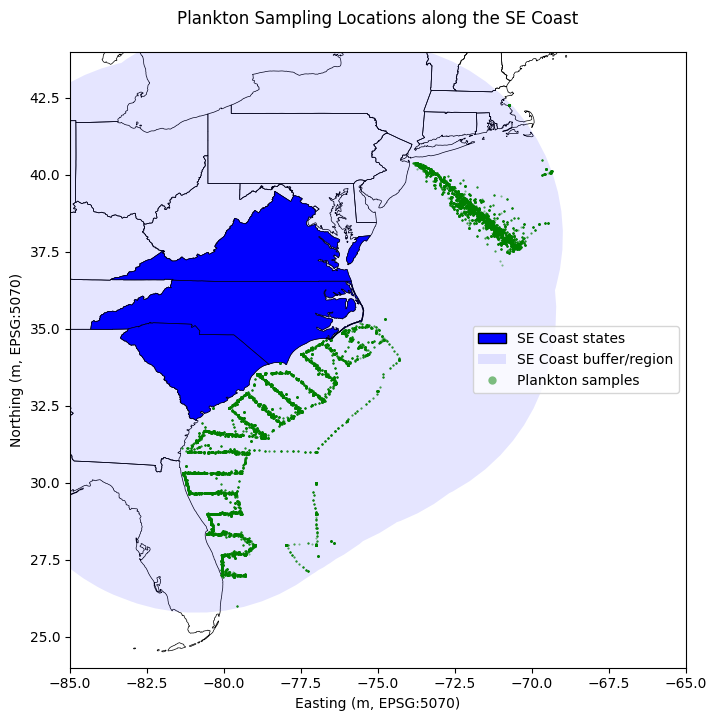

In [29]:
out_path = Path("../figures/jh_plankton_dataset_map.png")

ax = states.plot(edgecolor="black", facecolor="none", linewidth=0.5, figsize=(8, 8))
se_coast_states.plot(ax=ax, color="blue", alpha=1, edgecolor="black", linewidth=0.5)
se_coast_states_b.plot(ax=ax, color="blue", alpha=0.1)
gdf.plot(ax=ax, markersize=0.25, color="green", alpha=0.5)

handles = [
    Patch(facecolor="blue", edgecolor="black", alpha=1, label="SE Coast states"),
    Patch(
        facecolor="blue", edgecolor="none", alpha=0.1, label="SE Coast buffer/region"
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor="green",
        markeredgecolor="none",
        markersize=6,
        alpha=0.5,
        label="Plankton samples",
    ),
]
ax.legend(handles=handles, loc="center right", frameon=True)

ax.set_xlim(-85, -65)
ax.set_ylim(24, 44)
ax.set_title("Plankton Sampling Locations along the SE Coast", pad=20)
ax.set_xlabel("Easting (m, EPSG:5070)")
ax.set_ylabel("Northing (m, EPSG:5070)")
plt.savefig(out_path, dpi=300)

In [30]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 34495 entries, 764190 to 939253
Data columns (total 43 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   SHP-CRUISE                       34495 non-null  str           
 1   YEAR                             34495 non-null  int64         
 2   MON                              34495 non-null  int64         
 3   DAY                              34495 non-null  int64         
 4   TIMEgmt                          34495 non-null  float64       
 5   TIMEloc                          34495 non-null  float64       
 6   LATITUDE                         34495 non-null  float64       
 7   LONGITDE                         34495 non-null  float64       
 8   UPPER_Z                          34495 non-null  float64       
 9   LOWER_Z                          34495 non-null  float64       
 10  T                                34495 non-null  

In [31]:
gdf.drop(
    columns=[
        "geometry",
        "SHP-CRUISE",
        "T",
        "GEAR",
        "MESH",
        "ITIS_TSN",
        "MOD",
        "PSC",
        "SHIP",
        "PROJ",
        "INST",
    ]
).rename(
    columns={
        "YEAR": "year",
        "MON": "month",
        "DAY": "day",
        "TIMEgmt": "time_gmt",
        "TIMEloc": "time_local",
        "LATITUDE": "lat",
        "LONGITDE": "lon",
        "UPPER_Z": "upper_z",
        "LOWER_Z": "lower_z",
        "NMFS_PGC": "grouping_code",
        "LIF": "life_stage",
        "SEX": "sex",
        "V": "measurement_type",
        "Water Strained": "water_strained",
        "Original-VALUE": "original_value",
        "Orig-UNITS": "original_units",
        "VALUE-per-volu": "count",
        "UNITS": "count_units",
        "VALUE-per-volu-F1": "global_an_flag",
        "VALUE-per-volu-F2": "basin_annu_flag",
        "VALUE-per-volu-F3": "basin_seas_flag",
        "VALUE-per-volu-F4": "basin_mont_flag",
    }
).to_parquet(
    "../data/processed/copepod_dataset_se_coast.parquet",
    index=False,
)

In [32]:
df = pd.read_parquet("../data/processed/copepod_dataset_se_coast.parquet")
df

,year,month,day,time_gmt,time_local,lat,lon,upper_z,lower_z,grouping_code,...,VALUE-per-area,VALUE-per_area-UNITS,VALUE-per-area-F1,VALUE-per-area-F2,VALUE-per-area-F3,VALUE-per-area-F4,SCIENTIFIC NAME -[ modifiers ]-,RECORD-ID,DATASET-ID,date
0,1995,3,19,11.600,-99.000,40.047,-69.477,10.0,10.0,4320000,...,null,-----,-1,-1,-1,-1,"Chaetognatha ""CPR-TOTAL """"eyecount""""""",0008_0001,SAHFOS-CPR Atlantic Ocean,1995-03-19
1,1995,4,16,3.367,-99.000,40.113,-69.375,10.0,10.0,4212000,...,null,-----,-1,-1,-1,-1,Copepoda TOTAL (total count),0020_0005,SAHFOS-CPR Atlantic Ocean,1995-04-16
2,1995,4,16,3.367,-99.000,40.113,-69.375,10.0,10.0,4212010,...,null,-----,-1,-1,-1,-1,"Calanus ""CPR-TOTAL """"traverse""""""",0020_0004,SAHFOS-CPR Atlantic Ocean,1995-04-16
3,1995,4,16,3.367,-99.000,40.113,-69.375,10.0,10.0,4212010,...,null,-----,-1,-1,-1,-1,Calanus TOTAL (total count) -[ c5-6 ]-,0020_0007,SAHFOS-CPR Atlantic Ocean,1995-04-16
4,1995,4,16,3.367,-99.000,40.113,-69.375,10.0,10.0,4212010,...,null,-----,-1,-1,-1,-1,Calanus -[ c1-4 ]-,0020_0001,SAHFOS-CPR Atlantic Ocean,1995-04-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34490,1999,12,9,10.517,10.517,40.291,-73.550,10.0,10.0,4212010,...,null,-----,-1,-1,-1,-1,Pleuromamma borealis,0008_0007,EcoMon-SOOP (Mid-Atlantic Bight),1999-12-09
34491,1999,12,9,10.517,10.517,40.291,-73.550,10.0,10.0,4212040,...,null,-----,-1,-1,-1,-1,Oithona spp.,0008_0004,EcoMon-SOOP (Mid-Atlantic Bight),1999-12-09
34492,1999,12,9,10.517,10.517,40.291,-73.550,10.0,10.0,4217050,...,null,-----,-1,-1,-1,-1,Hyperiidea,0008_0014,EcoMon-SOOP (Mid-Atlantic Bight),1999-12-09
34493,1999,12,9,10.517,10.517,40.291,-73.550,10.0,10.0,4218000,...,null,-----,-1,-1,-1,-1,Euphausiacea,0008_0008,EcoMon-SOOP (Mid-Atlantic Bight),1999-12-09
